# Ugly data → Actionable table
**Goal:** Turn messy tracking/scan events into a decision‑ready daily table.  
Dataset target: Cargo 2000 (C2K) tracking events (or similar), plus a small synthetic `orders.csv` derived from scans.

**Our journey**
- *Ugly raw data*: out‑of‑order timestamps, near‑duplicates, inconsistent codes, poor formatting
- *Agentic cleanup graph*: normalize → infer milestones → join context → KPIs → ETA → risk → validate
- *Decision‑ready output*: `decision_ready_daily.parquet` + a one‑page daily summary

**Source data**
Kaggle Cargo 2000 dataset: https://www.kaggle.com/datasets/crawford/cargo-2000-dataset

In [24]:
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 160)

# Define paths
PROJECT_NAME = "ugly_data_langgraph"
DATA_DIR = Path(f"datasets/{PROJECT_NAME}")  # put your C2K scans here
OUT_DIR = Path(f"results/{PROJECT_NAME}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

# Define input / output files
IN_DATASET = DATA_DIR/"c2k_data.csv"
SCANS_DATASET = DATA_DIR/"c2k_scans.csv"

DECISION_RESULTS = OUT_DIR/"decision_ready_daily.parquet"
INTAKE_SUMMARY = OUT_DIR/"summary_data_case_start.parquet"
COMPLETION_SUMMARY = OUT_DIR/"summary_data_case_end.parquet"


DATA_DIR: /Users/douglasdaly/Documents/GitHub/Generative-AI/datasets/ugly_data_langgraph
OUT_DIR: /Users/douglasdaly/Documents/GitHub/Generative-AI/results/ugly_data_langgraph


## Load Data
The Cargo 2000 dataset demonstrates the tracking and tracing events related to air transport where each row is a separate shipment case. This example has 3 incoming legs entering a hub and one outgoing leg. Each leg may have up to 3 hops in its journey. The end-to-end system is in this diagram:</br>
![Cargo2000](./assets/cargo_2000_uml.png)</br>
The feedback arrows denote multiple hops within a leg.</br></br>
There are 4 services tracked by Cargo 2000 in the diagram:
<ul><li>RCS: Check in freight at departure airline. Shipment is checked in and a receipt is produced at departure airport.</li>
<li>DEP: Confirm goods on board. Aircraft has departed with shipment on board.</li>
<li>RCF: Accept freight at arrival airline. Shipment is checked in according to the documents and stored at arrival warehouse.</li>
<li>DLV: Deliver freight. Receipt of shipment was signed at destination airport.</li></ul>

In [38]:
# Load the Cargo 2000 dataset
case_df = pd.read_csv(IN_DATASET)
print(case_df.head())
print(case_df.columns)

    nr  i1_legid  i1_rcs_p  i1_rcs_e  i1_dep_1_p  i1_dep_1_e  i1_dep_1_place  i1_rcf_1_p  i1_rcf_1_e  i1_rcf_1_place  ... o_dep_3_p o_dep_3_e o_dep_3_place  \
0  0.0    5182.0     199.0     218.0       210.0       215.0           609.0       935.0       736.0           256.0  ...         ?         ?             ?   
1  1.0    6523.0     844.0     584.0        90.0       297.0           700.0      1935.0      1415.0           431.0  ...         ?         ?             ?   
2  2.0    5878.0    4380.0    4119.0        90.0       280.0           456.0       905.0       547.0           700.0  ...         ?         ?             ?   
3  3.0    1275.0     759.0     169.0       240.0       777.0           173.0       340.0       577.0           349.0  ...         ?         ?             ?   
4  4.0    8117.0    1597.0    1485.0       150.0       241.0           411.0       585.0       612.0           128.0  ...         ?         ?             ?   

  o_rcf_3_p o_rcf_3_e o_rcf_3_place o_dlv_p o

The table has 98 columns which are (roughly): (leg)_(service)_(arrival-segment)_(metric) </br>
<ul><li><b>leg</b>: i1 to i3 (incoming) or o (outgoing)</li>
<li><b>service</b>: RCS, DEP, RCF, DLV - mentioned above</li>
<li><b>arrival-segment</b>: hop # within the leg (1-3)</li>
<li><b>metric</b>: 'e' (effective or actual duration), 'p' (planned duration), 'place' (masked airport code), 'hops' (number of hops in the leg)</li></ul>
</br>All duration measures are in minutes.

## Data Pipeline Objective
Build a data pipeline such that tracking on-time shipment events are straightforward. Provide shipment metadata to enable delivery success risk models can be created.
## Process
### Data Processing
<ul><li>Identify, clean and convert numeric fields</li>
<li>Convert minutes between stops into timestamps. (Assume START_DATE.)</li>
<li>Create SCANS table -- each row is separate scan. Useful for shipment timeliness.</li>
<li>Normalize dataset w/ human readable events and uniform timezone.</li>
<li>Determine milestones (pick-up, at hub, out for delivery, delivered) from events</li>

In [43]:
# ---------- imports ----------
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import timezone

# ---------- 0) helpers ----------
def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    num_cols = out.filter(regex=r"(_p|_e|_hops)$").columns
    out[num_cols] = (out[num_cols]
                     .replace(r"[^0-9\.\-]", "", regex=True)
                     .apply(pd.to_numeric, errors="coerce")
                     .fillna(0))
    hop_cols = out.filter(regex=r"_hops$").columns
    if len(hop_cols):
        out[hop_cols] = out[hop_cols].astype(int)
    return out

def to_utc_series(s: pd.Series) -> pd.Series:
    s = pd.to_datetime(s, errors="coerce")
    # localize naive → UTC; keep tz if present, convert → UTC
    return s.apply(lambda x: x.tz_localize("UTC") if (pd.notna(x) and x.tzinfo is None)
                   else (x.tz_convert("UTC") if pd.notna(x) else x))

def assert_monotonic(scans: pd.DataFrame):
    ok = scans.sort_values(["case_id","event_ts"])\
              .groupby("case_id")["event_ts"]\
              .apply(lambda s: s.is_monotonic_increasing).all()
    if not ok:
        raise AssertionError("event_ts not monotonic within some case_id")

# ---------- 1) load raw → case_df ----------
def load_case_df(path: str) -> pd.DataFrame:
    case_df = pd.read_csv(path)
    if "nr" not in case_df.columns:
        raise ValueError("Expected 'nr' in the raw file.")
    case_df = coerce_numeric(case_df)
    case_df = case_df.rename(columns={"nr": "case_id"})
    case_df["case_id"] = case_df["case_id"].astype(str)
    return case_df


# ---------- 2) build synthetic scans (i1–i3 parallel → merge → o) ----------
def _pick_minutes(row, e_col, p_col):
    e = pd.to_numeric(row.get(e_col), errors="coerce")
    p = pd.to_numeric(row.get(p_col), errors="coerce")
    val = e if pd.notna(e) and e >= 0 else (p if pd.notna(p) and p >= 0 else 0.0)
    return float(val)

def _leg_spec(prefix: str):
    return dict(
        rcs_p=f"{prefix}_rcs_p",   rcs_e=f"{prefix}_rcs_e",
        dep_p=[f"{prefix}_dep_{k}_p" for k in [1,2,3]],
        dep_e=[f"{prefix}_dep_{k}_e" for k in [1,2,3]],
        dep_place=[f"{prefix}_dep_{k}_place" for k in [1,2,3]],
        rcf_p=[f"{prefix}_rcf_{k}_p" for k in [1,2,3]],
        rcf_e=[f"{prefix}_rcf_{k}_e" for k in [1,2,3]],
        rcf_place=[f"{prefix}_rcf_{k}_place" for k in [1,2,3]],
        dlv_p=f"{prefix}_dlv_p",   dlv_e=f"{prefix}_dlv_e",
        hops=f"{prefix}_hops",
    )

LEG_SPECS = {"i1":_leg_spec("i1"), "i2":_leg_spec("i2"), "i3":_leg_spec("i3"), "o":_leg_spec("o")}

def build_scans(case_df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    if "case_id" not in case_df.columns:
        case_df = case_df.rename(columns={"nr":"case_id"})
    case_df = case_df.copy()
    case_df["case_id"] = case_df["case_id"].astype(str)

    rng = np.random.default_rng(seed)
    start_anchor = pd.Timestamp("2025-07-01 08:00:00", tz="UTC")
    rows = []

    # ---- helpers (inside function, outside loop) ----
    def legs_used_from_row(r):
        return int((r.get("i1_hops",0)>0) + (r.get("i2_hops",0)>0) + (r.get("i3_hops",0)>0))

    def total_hops_in_from_row(r):
        return int((r.get("i1_hops",0) or 0) + (r.get("i2_hops",0) or 0) + (r.get("i3_hops",0) or 0))

    def incoming_overrun_minutes(r):
        def over(e, p):
            e_ = pd.to_numeric(r.get(e), errors="coerce")
            p_ = pd.to_numeric(r.get(p), errors="coerce")
            if pd.isna(e_) or pd.isna(p_): return 0.0
            return float(max(e_ - p_, 0))
        tot = 0.0
        for leg in ["i1","i2","i3"]:
            tot += over(f"{leg}_rcs_e", f"{leg}_rcs_p")
            for k in (1,2,3):
                tot += over(f"{leg}_dep_{k}_e", f"{leg}_dep_{k}_p")
                tot += over(f"{leg}_rcf_{k}_e", f"{leg}_rcf_{k}_p")
            tot += over(f"{leg}_dlv_e", f"{leg}_dlv_p")
        return tot

    def sample_handling_buffer_minutes(r, rng):
        base = float(np.exp(rng.normal(np.log(60), 0.35)))           # ~median 60
        legs = legs_used_from_row(r)
        hops_in = total_hops_in_from_row(r)
        complexity = 15.0 * max(legs-1, 0) + 6.0 * max(hops_in-1, 0)
        congestion = 0.02 * incoming_overrun_minutes(r)              # +1 min / 50 overrun min
        noise = float(rng.normal(0, 10))
        return float(min(max(20.0, base + complexity + congestion + noise), 360.0))

    def _pick_minutes(r, e_col, p_col):
        e = pd.to_numeric(r.get(e_col), errors="coerce")
        p = pd.to_numeric(r.get(p_col), errors="coerce")
        v = e if pd.notna(e) and e >= 0 else (p if pd.notna(p) and p >= 0 else 0.0)
        return float(v)

    def add_event(acc, cid, ts, code, leg, seg=None, place=None):
        acc.append({
            "case_id": cid,
            "event_ts": pd.to_datetime(ts, utc=True),
            "event_code": code,
            "leg": leg,
            "seg": seg,
            "place_id": place
        })

    def build_leg(r, cid, leg: str, base_ts: pd.Timestamp):
        spec = LEG_SPECS[leg]
        cum = 0.0
        evs = []

        rcs = _pick_minutes(r, spec["rcs_e"], spec["rcs_p"])
        if rcs > 0:
            add_event(evs, cid, base_ts + pd.to_timedelta(cum, unit="m"), "RCS", leg); cum += rcs

        for k, (dep_e, dep_p, dep_place, rcf_e, rcf_p, rcf_place) in enumerate(
            zip(spec["dep_e"], spec["dep_p"], spec["dep_place"], spec["rcf_e"], spec["rcf_p"], spec["rcf_place"]), start=1):
            dep = _pick_minutes(r, dep_e, dep_p)
            rcf = _pick_minutes(r, rcf_e, rcf_p)
            if dep > 0:
                add_event(evs, cid, base_ts + pd.to_timedelta(cum, unit="m"), "DEP", leg, seg=k, place=r.get(dep_place, np.nan)); cum += dep
            if rcf > 0:
                add_event(evs, cid, base_ts + pd.to_timedelta(cum, unit="m"), "RCF", leg, seg=k, place=r.get(rcf_place, np.nan)); cum += rcf

        dlv = _pick_minutes(r, spec["dlv_e"], spec["dlv_p"])
        if dlv > 0:
            add_event(evs, cid, base_ts + pd.to_timedelta(cum, unit="m"), "DLV", leg); cum += dlv

        end_ts = evs[-1]["event_ts"] if evs else None
        return evs, end_ts

    # ---- per-case loop ----
    for _, r in case_df.iterrows():
        cid = str(r["case_id"])

        base_offsets = {leg: pd.to_timedelta(int(rng.integers(0, 240)), unit="m") for leg in ["i1","i2","i3"]}
        incoming_events, incoming_ends = [], []

        # Incoming legs
        for leg in ["i1","i2","i3"]:
            spec = LEG_SPECS[leg]
            hops = int(r.get(spec["hops"], 0) or 0)
            any_min = (
                _pick_minutes(r, spec["rcs_e"], spec["rcs_p"]) +
                sum(_pick_minutes(r, e, p) for e, p in zip(spec["dep_e"], spec["dep_p"])) +
                sum(_pick_minutes(r, e, p) for e, p in zip(spec["rcf_e"], spec["rcf_p"])) +
                _pick_minutes(r, spec["dlv_e"], spec["dlv_p"])
            )
            if hops > 0 or any_min > 0:
                base_ts = start_anchor + pd.to_timedelta(int(rng.integers(0, 60*24*30)), unit="m") + base_offsets[leg]
                evs, end_ts = build_leg(r, cid, leg, base_ts)
                incoming_events.extend(evs)
                if end_ts is not None:
                    incoming_ends.append(end_ts)

        terminal_ready = max(incoming_ends) if incoming_ends else (start_anchor + pd.to_timedelta(int(rng.integers(0, 60*24*30)), unit="m"))

        # Outgoing leg with stochastic handling buffer
        handling_buffer_min = sample_handling_buffer_minutes(r, rng)
        o_base = terminal_ready + pd.to_timedelta(handling_buffer_min, unit="m")
        o_evs, _ = build_leg(r, cid, "o", o_base)

        all_evs = incoming_events + o_evs

        # jitter ±60s to break ties
        for ev in all_evs:
            ev["event_ts"] = ev["event_ts"] + pd.to_timedelta(int(rng.integers(-60, 61)), unit="s")
        rows.extend(all_evs)

    # ---- finalize ----
    scans = pd.DataFrame(rows)
    required = {"case_id","event_ts","event_code"}
    missing = required - set(scans.columns)
    if missing:
        sample = rows[0] if rows else {}
        raise RuntimeError(f"Missing {missing}; sample keys={list(sample.keys())}")
    scans = scans.sort_values(["case_id","event_ts"]).reset_index(drop=True)
    assert_monotonic(scans)
    return scans


# ---------- 3) normalize codes & infer milestones ----------
CODE_MAP = {"rcs":"pickup", "dep":"hub_out", "rcf":"hub_in", "dlv":"delivered"}

def normalize_scans(scans: pd.DataFrame) -> pd.DataFrame:
    s = scans.copy()
    s["event_ts"] = to_utc_series(s["event_ts"])
    s["event_code"] = (s["event_code"].astype(str).str.strip().str.lower()
                       .str.replace(r"[^a-z]+","", regex=True)
                       .map(CODE_MAP).fillna(s["event_code"].astype(str).str.lower()))
    # drop near-dupes within 5 minutes, same code
    s = s.sort_values(["case_id","event_ts"]).reset_index(drop=True)
    s["prev_ts"] = s.groupby("case_id")["event_ts"].shift()
    s["prev_code"] = s.groupby("case_id")["event_code"].shift()
    keep = ~((s["event_code"]==s["prev_code"]) & ((s["event_ts"] - s["prev_ts"]).dt.total_seconds().fillna(999999) <= 300))
    s = s[keep].drop(columns=["prev_ts","prev_code"])
    assert_monotonic(s)
    return s

def infer_case_milestones(scans_norm: pd.DataFrame) -> pd.DataFrame:
    s = scans_norm.sort_values(["case_id","event_ts"])
    rows = []
    for cid, g in s.groupby("case_id", sort=False):
        first = lambda code: g.loc[g["event_code"]==code, "event_ts"].min()
        row = {
            "case_id": cid,
            "case_start_ts": g["event_ts"].min(),
            "first_hub_in_ts": first("hub_in"),
            "first_hub_out_ts": first("hub_out"),
            "case_end_ts": g["event_ts"].max(),
        }
        if "leg" in g.columns:
            for leg in ["i1","i2","i3","o"]:
                gl = g[g["leg"]==leg]
                if len(gl):
                    row[f"{leg}_start_ts"] = gl["event_ts"].min()
                    row[f"{leg}_end_ts"]   = gl["event_ts"].max()
        rows.append(row)
    out = pd.DataFrame(rows)
    # tz safety
    for c in out.filter(like="_ts").columns:
        out[c] = to_utc_series(out[c])
    return out

# ---------- 4) compute case features from the raw case_df ----------
def compute_case_features(case_df: pd.DataFrame) -> pd.DataFrame:
    df = case_df.copy()
    df["legs_used"] = ((df.get("i1_hops",0)>0).astype(int) + (df.get("i2_hops",0)>0).astype(int) + (df.get("i3_hops",0)>0).astype(int))
    df["total_hops_in"]  = (df.get("i1_hops",0) + df.get("i2_hops",0) + df.get("i3_hops",0)).astype(int)
    df["total_hops_all"] = (df["total_hops_in"] + df.get("o_hops",0)).astype(int)

    plan_cols = df.filter(regex=r"_p$").columns
    eff_cols  = df.filter(regex=r"_e$").columns
    df["planned_minutes_total"]   = df[plan_cols].sum(axis=1)
    df["effective_minutes_total"] = df[eff_cols].sum(axis=1)
    df["overrun_minutes"]         = df["effective_minutes_total"] - df["planned_minutes_total"]

    return df[["case_id","legs_used","total_hops_in","total_hops_all",
               "planned_minutes_total","effective_minutes_total","overrun_minutes"]]

# ---------- 5) assemble case_view + optional risk ----------
def assemble_case_view(milestones: pd.DataFrame, case_features: pd.DataFrame) -> pd.DataFrame:
    cv = milestones.merge(case_features, on="case_id", how="left")

    incoming_end_cols = [c for c in ["i1_end_ts","i2_end_ts","i3_end_ts"] if c in cv.columns]
    cv["incoming_done_ts"] = cv[incoming_end_cols].max(axis=1, skipna=True)
    # first outgoing touch time
    cv["o_first_touch_ts"] = cv.filter(regex=r"^o_(start|rcs|end)_ts$").min(axis=1)

    cv["terminal_wait_min"] = ((cv["o_first_touch_ts"] - cv["incoming_done_ts"]).dt.total_seconds()/60).astype("float")
    cv["total_transit_hours"] = ((cv["case_end_ts"] - cv["case_start_ts"]).dt.total_seconds()/3600).astype("float")

    # simple, optional case risk (no orders)
    over = pd.to_numeric(cv["overrun_minutes"], errors="coerce").fillna(0)
    z = (over - over.mean()) / (over.std(ddof=0) + 1e-6)
    wait = pd.to_numeric(cv["terminal_wait_min"], errors="coerce").fillna(0) / 120.0  # normalize by 2h
    raw = 0.5*wait + 0.5*np.clip((z+2)/4, 0, 1)
    cv["case_risk_score"] = raw.clip(0,1)
    cv["exception_flag"] = (cv["terminal_wait_min"] > 120) | (cv["overrun_minutes"] > 180)
    cv["primary_delay_reason"] = np.where(cv["terminal_wait_min"] > 120, "terminal_queue",
                                   np.where(cv["overrun_minutes"] > 180, "plan_overrun","none"))
    return cv

# ---------- 6) daily summaries (case-anchored) ----------
def summarize_daily_cases(case_view: pd.DataFrame, tz="America/Los_Angeles"):
    df = case_view.copy()
    for c in ["case_start_ts","case_end_ts"]:
        df[c] = to_utc_series(df[c]).dt.tz_convert(tz)

    df["start_day"] = df["case_start_ts"].dt.date
    df["end_day"]   = df["case_end_ts"].dt.date

    # completion-anchored
    done = df.dropna(subset=["end_day"])
    keep_cols = ["overrun_minutes","terminal_wait_min","case_risk_score","exception_flag"]
    daily_end = (
        done[["end_day"] + keep_cols]
        .groupby("end_day", dropna=False)
        .apply(lambda g: pd.Series({
            "cases": len(g),
            "exceptions": int(g["exception_flag"].sum()),
            "avg_overrun_min": float(pd.to_numeric(g["overrun_minutes"]).mean()),
            "avg_terminal_wait_min": float(pd.to_numeric(g["terminal_wait_min"]).mean()),
            "risk_p95": float(np.nanpercentile(pd.to_numeric(g["case_risk_score"]), 95)),
        }))
        .reset_index().rename(columns={"end_day":"day"}).sort_values("day")
    )

    # 7d rolling (min_periods=1)
    r = daily_end.set_index("day")
    r["cases_7d"] = r["cases"].rolling(7, min_periods=1).sum()
    r["exceptions_7d"] = r["exceptions"].rolling(7, min_periods=1).sum()
    r["avg_overrun_min_7d"] = (r["avg_overrun_min"] * r["cases"]).rolling(7, min_periods=1).sum() / r["cases_7d"].replace(0,np.nan)
    r["avg_terminal_wait_min_7d"] = (r["avg_terminal_wait_min"] * r["cases"]).rolling(7, min_periods=1).sum() / r["cases_7d"].replace(0,np.nan)
    daily_end = r.reset_index()

    # intake-anchored
    daily_start = (
        df[["start_day","exception_flag"]]
        .groupby("start_day", dropna=False)
        .agg(cases=("exception_flag","size"), exceptions=("exception_flag","sum"))
        .reset_index().rename(columns={"start_day":"day"}).sort_values("day")
    )
    rs = daily_start.set_index("day")
    rs["cases_7d"] = rs["cases"].rolling(7, min_periods=1).sum()
    rs["exceptions_7d"] = rs["exceptions"].rolling(7, min_periods=1).sum()
    daily_start = rs.reset_index()

    # save
    daily_end.to_parquet(COMPLETION_SUMMARY, index=False)
    daily_start.to_parquet(INTAKE_SUMMARY, index=False)
    return daily_start, daily_end


In [44]:

# ---------- usage ----------
case_df   = load_case_df(IN_DATASET)
scans_df  = build_scans(case_df)
scans_norm= normalize_scans(scans_df)
milestones= infer_case_milestones(scans_norm)
features  = compute_case_features(case_df)
case_view = assemble_case_view(milestones, features)

case_view.to_parquet(DECISION_RESULTS, index=False)
daily_start, daily_end = summarize_daily_cases(case_view)


/var/folders/2d/nd_kkrs166v10fz9h75cg5v00000gn/T/ipykernel_46364/735780517.py:295: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## Visuals & Insight

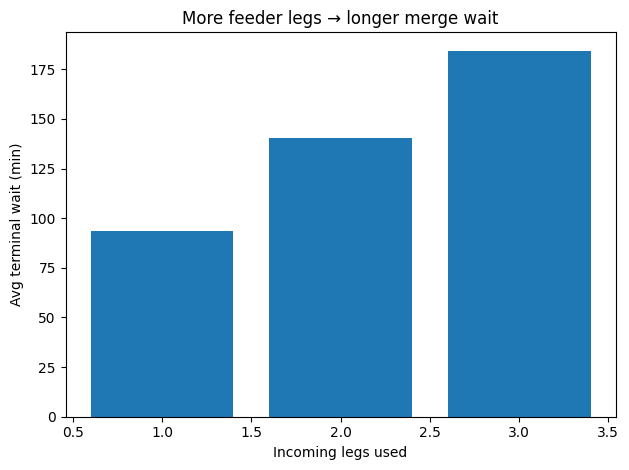

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

g = (case_view
     .groupby("legs_used", dropna=False)["terminal_wait_min"]
     .mean().reset_index())

plt.figure()
plt.bar(g["legs_used"].astype(int), g["terminal_wait_min"])
plt.xlabel("Incoming legs used")
plt.ylabel("Avg terminal wait (min)")
plt.title("More feeder legs → longer merge wait")
plt.tight_layout()


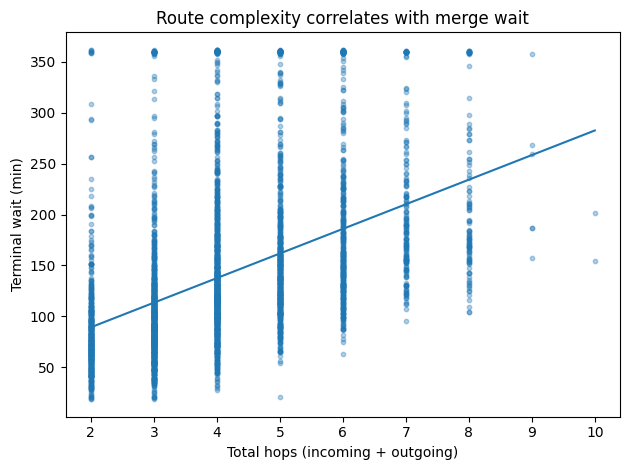

In [46]:
import numpy as np
import matplotlib.pyplot as plt

df = case_view.copy()
x = pd.to_numeric(df["total_hops_all"], errors="coerce")
y = pd.to_numeric(df["terminal_wait_min"], errors="coerce")

mask = x.notna() & y.notna()
xv, yv = x[mask], y[mask]

plt.figure()
plt.scatter(xv, yv, alpha=0.35, s=10)
# quick linear fit line
coef = np.polyfit(xv, yv, 1)
xx = np.linspace(xv.min(), xv.max(), 100)
yy = coef[0]*xx + coef[1]
plt.plot(xx, yy)

plt.xlabel("Total hops (incoming + outgoing)")
plt.ylabel("Terminal wait (min)")
plt.title("Route complexity correlates with merge wait")
plt.tight_layout()


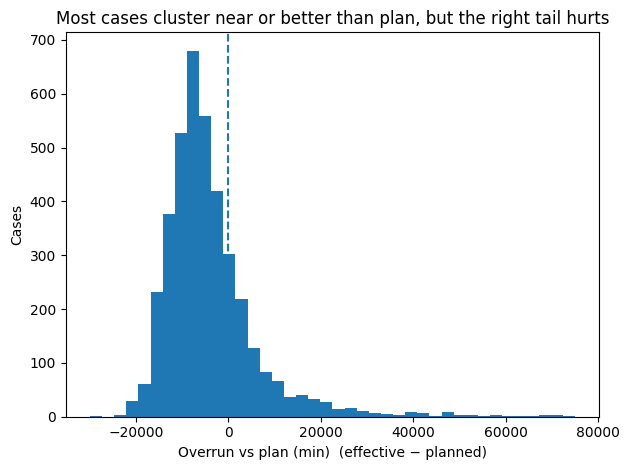

In [51]:
import matplotlib.pyplot as plt

ov = pd.to_numeric(case_view["overrun_minutes"], errors="coerce").dropna()

plt.figure()
plt.hist(ov, bins=40, range=[-30000,75000])
plt.axvline(0, linestyle="--")
plt.xlabel("Overrun vs plan (min)  (effective − planned)")
plt.ylabel("Cases")
plt.title("Most cases cluster near or better than plan, but the right tail hurts")
plt.tight_layout()


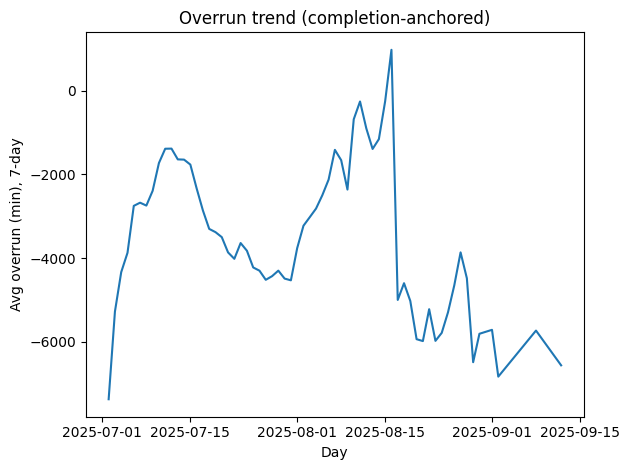

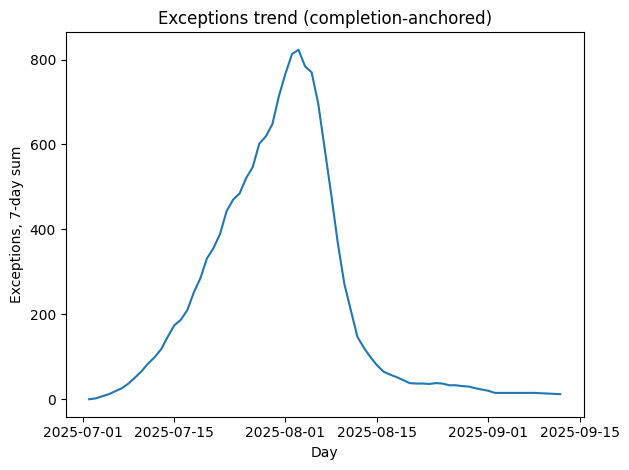

In [48]:
import matplotlib.pyplot as plt

d = daily_end.sort_values("day").copy()

plt.figure()
plt.plot(d["day"], d["avg_overrun_min_7d"])
plt.xlabel("Day")
plt.ylabel("Avg overrun (min), 7-day")
plt.title("Overrun trend (completion-anchored)")
plt.tight_layout()

plt.figure()
plt.plot(d["day"], d["exceptions_7d"])
plt.xlabel("Day")
plt.ylabel("Exceptions, 7-day sum")
plt.title("Exceptions trend (completion-anchored)")
plt.tight_layout()
